# Evaluate Trading Signals

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from boosting_utils import (
    FEATURES, baseline_models, ensure_output_dir, fit_best_classifier, fit_regressor,
    long_short_backtest, make_boosting_panel, make_intraday_features, model_interpretation,
    score_quantiles, tune_gbm
)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
OUTPUT = ensure_output_dir()


In [2]:
panel = make_boosting_panel(seed=126)
_, scored, metrics = fit_best_classifier(panel)
quality = score_quantiles(scored)
quality.to_csv(OUTPUT / 'boosting_signal_quality.csv', index=False)
quality

,bucket,mean,std,count
0,1,0.0022,0.0330,3440
1,2,0.0032,0.0337,3440
2,3,0.0037,0.0330,3440
3,4,0.0032,0.0332,3440
4,5,0.0039,0.0330,3440


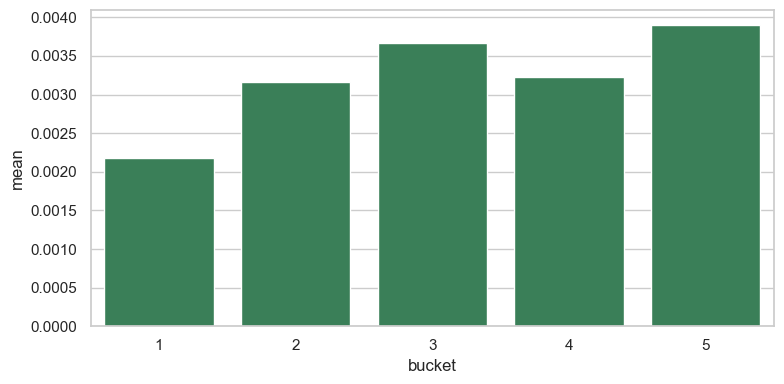

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=quality, x='bucket', y='mean', ax=ax, color='seagreen')
plt.tight_layout()